In [1]:
#we may need some code in the ../python directory and/or matplotlib styles
import sys
sys.path.append('../python/')

#matplotlib for plotting
import matplotlib as mpl
from matplotlib import pyplot as plt
plt.style.use('../mplstyles/stylelib/standard.mplstyle')

#other computational libraries
import numpy as np
import pandas as pds
import math

In [2]:
R = 1
h = 1
lmax = np.sqrt((2*R)**2+h**2)
l = np.linspace(2*R,lmax,1000)
a = 3
p = (2*R/l)*np.power((1-(2*R/l)**2),(a-1)/2)
cLMax = l<lmax
p = p[cLMax]
l = l[cLMax]

In [3]:
#print(p)

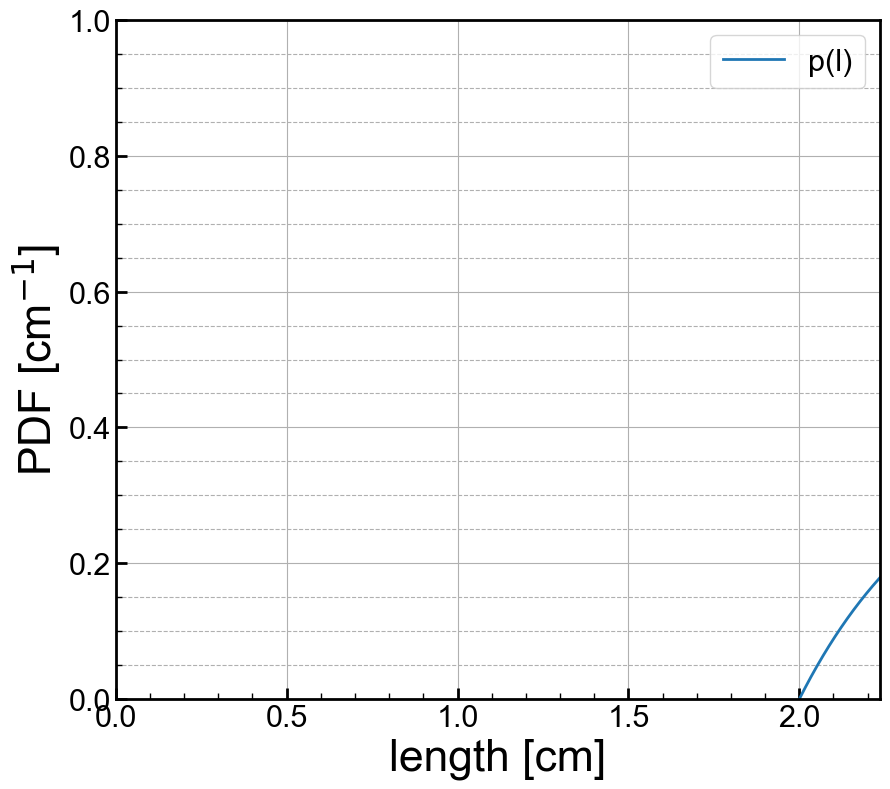

In [4]:
#set up a 1d plot
fig,axes = plt.subplots(1,1,figsize=(9.0,8.0),sharex=True)
ax1 = axes


#print(estring)
#ax1.plot(Er, dRlow,label='low res')
ax1.plot(l, p,label="p(l)")



ymin = 0
ymax = 1

blue = '#118DFA'
#ax1.fill_between(xcq,np.zeros(np.shape(xcq)),thist,step='mid',facecolor='b',alpha=0.4, \
#                 label='')

plt.grid()
ax1.set_yscale('linear')
#ax1.set_yscale('log')
ax1.set_xlim(0, lmax) 
ax1.set_ylim(ymin,ymax)
ax1.set_xlabel(r'length [cm]')
ax1.set_ylabel('PDF [cm$^{-1}$]')
ax1.grid(True)
ax1.yaxis.grid(True,which='minor',linestyle='--')
ax1.legend(loc=1,prop={'size':22})
#ax1.legend(bbox_to_anchor=(1.04,1),borderaxespad=0,prop={'size':22})

for axis in ['top','bottom','left','right']:
  ax1.spines[axis].set_linewidth(2)

plt.tight_layout()
#plt.savefig('figures/ne-recspec-Eee.png')
plt.show()

In [5]:
#the monte carlo way
L = 10
Nrad = 10
X = np.random.uniform(-L,L,Nrad)
Y = np.random.uniform(-L,L,Nrad)
R0 = np.sqrt(X**2,Y**2)
print(R0)

cOut = R0>R
R0 = R0[cOut]

[1.94607751 3.93632799 0.22635145 0.27893157 3.63586839 1.7551648
 6.13737667 0.25544492 1.47746051 2.09075473]


In [6]:
from scipy import integrate
#def cos_int(x):
#  f = lambda u: (a+1)*np.power(u,a)
#  return integrate.quad(f,0,x)[0]

def cos_int(x):
    f = lambda u: (a + 1) * np.power(u, a)

    if np.isscalar(x):
        return integrate.quad(f, 0, x)[0]
    else:
        return np.array([integrate.quad(f, 0, xi)[0] for xi in x])

print(cos_int(0.9999999))

from scipy import optimize
#def inv_cos_int(y):
#  g = lambda v: cos_int(v)-y
#  return optimize.root(g,0.5).x[0]

def inv_cos_int(y):
    
    def solve_one(yi):
        g = lambda v: cos_int(v) - yi
        return optimize.root(g, 0.5).x[0]

    if np.isscalar(y):
        return solve_one(y)
    else:
        y = np.asarray(y)
        return np.array([solve_one(yi) for yi in y])

print(inv_cos_int([0.5,0.6]))
print(cos_int(0.8409))


0.9999996000000603
[0.84089642 0.88011174]
0.500008526066096


In [16]:
N = 100
for r in R0:
  print(R/r)
  phi = np.random.uniform(-np.arcsin(R/r),np.arcsin(R/r),N)
  t = 2*np.sqrt(R**2 - r**2*np.sin(phi)**2)
  d = r*np.cos(phi) - np.sqrt(R**2 - r**2*np.sin(phi)**2)
  inv_costhet = np.random.uniform(0,1,N)
  costhet = inv_cos_int(inv_costhet)
  lcomp = t/np.sqrt(1-costhet**2)
  mincos = (d+t)/np.sqrt((d+t)**2+h**2)
  cCos = (costhet<1)&(costhet>=mincos)
  print(t[cCos])


#inv_costhet = np.random.uniform(0,1,N)
#costhet = inv_cos_int(inv_costhet)

0.5138541465818064
[1.41118543 1.91883483 1.05655154 1.50437415 1.2147325  1.25893725
 0.65241269 1.91063005 1.86472288 1.62591052 1.12455141 1.46562959
 1.93510283 1.83802617 1.06235393 1.21724704 1.78390122 1.82003009
 1.37670207 1.76002121 1.32853045 1.99990292 1.73512997 1.96199076
 1.59231884 1.92624227 1.97706818 1.04095789 1.65476847 1.922615  ]
0.2540438710372311
[1.92770406 1.06684238 1.56395394 1.27611941 1.89916034 1.56295534
 1.90913624 1.17304041 1.09349494 0.96238371]
0.2750374581697541
[1.99977916 1.99124813 1.46482657 1.99997765 1.99962203 1.76154873
 1.97805191 1.8001629  0.32718387 0.99812231 1.25007506 0.8584052 ]
0.5697470672929903
[1.43246733 1.92818119 1.90143576 1.40874952 1.43300353 1.22657528
 1.59879513 1.97112591 1.30665304 1.88480335 1.87545234 1.89169185
 1.80516068 1.60031549 0.12599301 1.83298894 0.75959062 0.85820985
 1.91114166 1.99436182 1.65884807 1.56764329 0.82178804 1.24496928
 1.77451807 0.83544229 0.36392991 1.91013461 1.56390663 1.81324071
 0.26

In [8]:
print(costhet)

[0.90539616 0.70290134 0.77430367 0.65310404 0.93221996 0.37651894
 0.91033517 0.69576294 0.58301571 0.39805908]


In [9]:
lcomp = t/np.sqrt(1-costhet**2)

In [10]:
print(lcomp)

[4.40916364 2.64235352 2.91675472 1.17466737 5.51511095 2.11604775
 4.76393417 2.29108322 2.04060836 2.16314423]
